First 5 Rows:
   ORDERNUMBER  QUANTITYORDERED  PRICEEACH  ORDERLINENUMBER    SALES  \
0        10107               30      95.70                2  2871.00   
1        10121               34      81.35                5  2765.90   
2        10134               41      94.74                2  3884.34   
3        10145               45      83.26                6  3746.70   
4        10159               49     100.00               14  5205.27   

         ORDERDATE   STATUS  QTR_ID  MONTH_ID  YEAR_ID  ...  \
0   2/24/2003 0:00  Shipped       1         2     2003  ...   
1    5/7/2003 0:00  Shipped       2         5     2003  ...   
2    7/1/2003 0:00  Shipped       3         7     2003  ...   
3   8/25/2003 0:00  Shipped       3         8     2003  ...   
4  10/10/2003 0:00  Shipped       4        10     2003  ...   

                    ADDRESSLINE1  ADDRESSLINE2           CITY STATE  \
0        897 Long Airport Avenue           NaN            NYC    NY   
1             59 rue de l'Abbaye

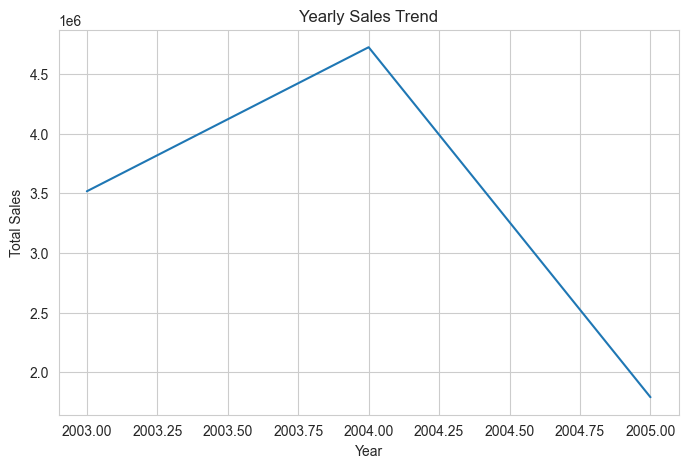

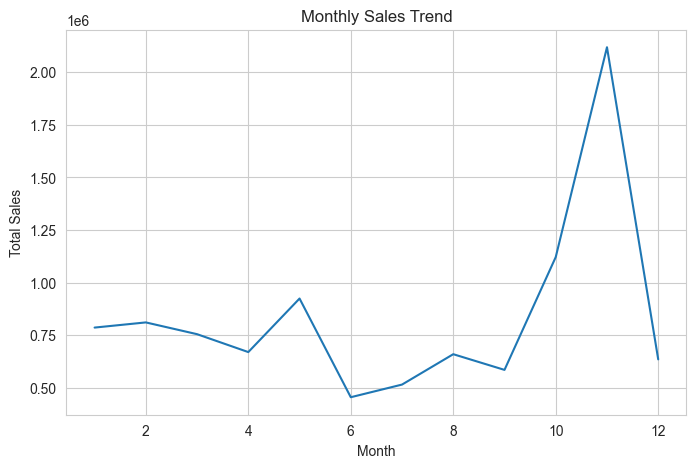

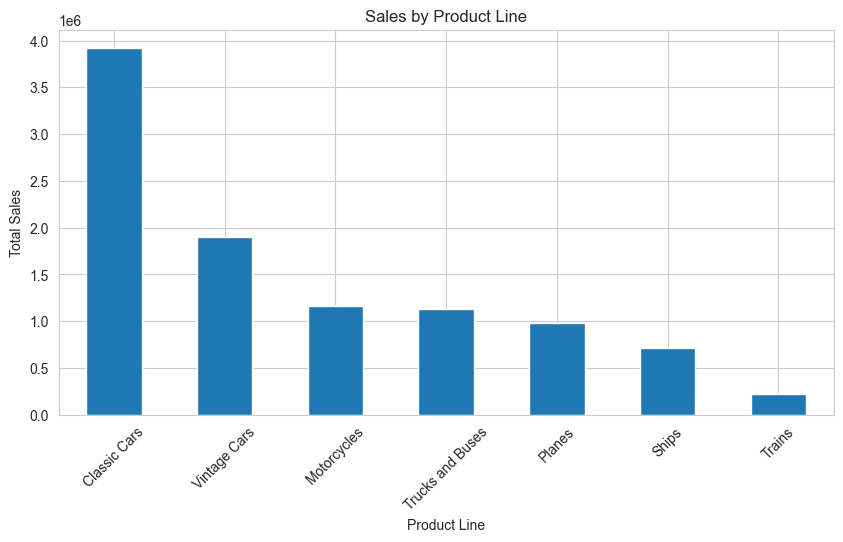

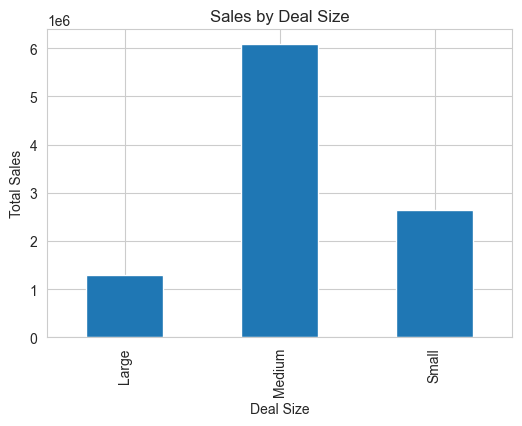

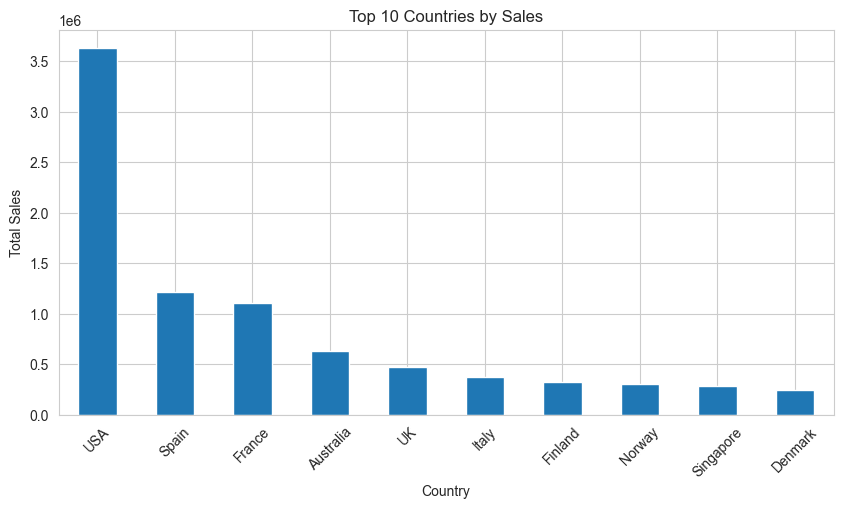

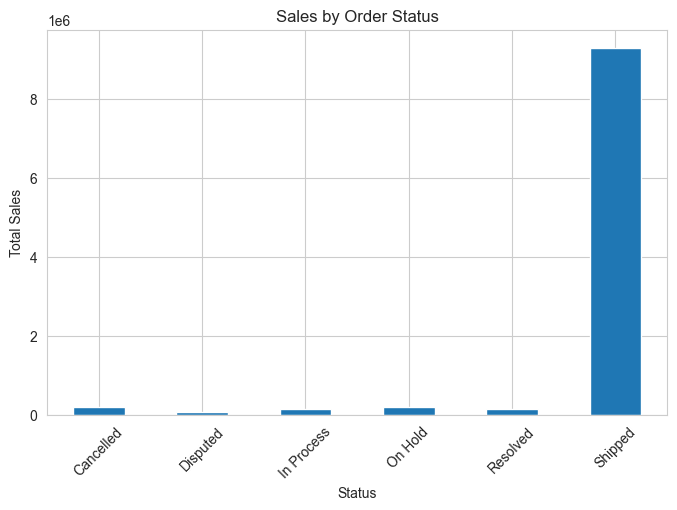

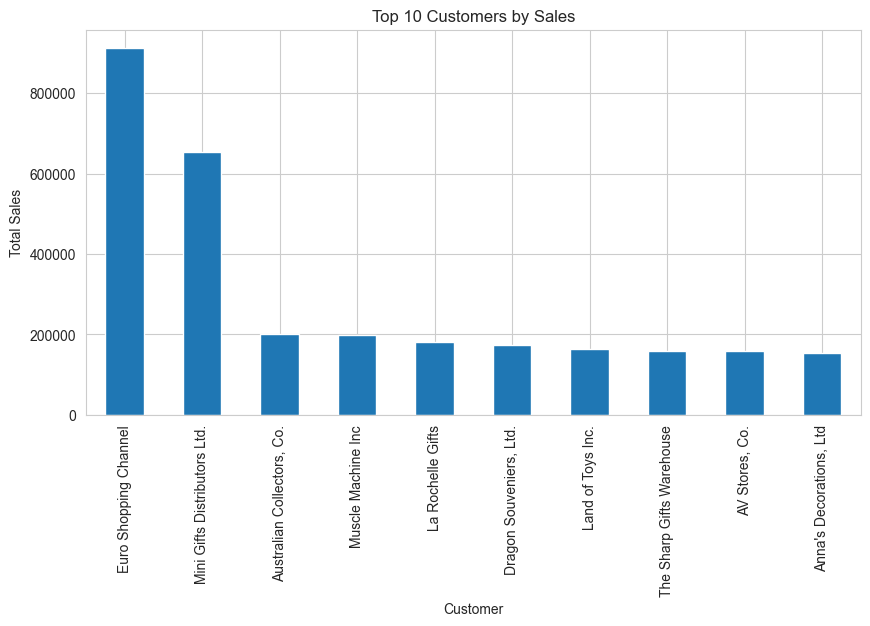

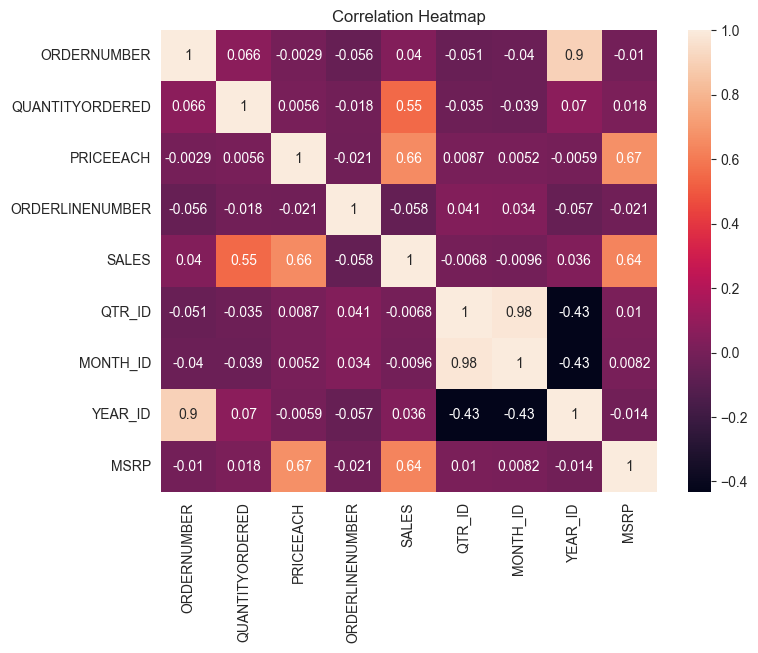


 COMPLETE SALES ANALYSIS FINISHED SUCCESSFULLY!


In [ ]:
# =========================================================
# 📊 COMPLETE SALES DATA ANALYSIS PROJECT
# Objective: Analyze trends, seasonality & product performance
# Dataset: Kaggle Sales Data (Classic Models)
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

# ===============================
# 1️ Load Dataset
# ===============================
# Read with utf-8-sig to remove BOM if present and normalize column names
df = pd.read_csv("sales data.csv", encoding='utf-8-sig')
df.columns = df.columns.str.strip().str.replace('\ufeff', '', regex=False)

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())

# ===============================
# 2️ Data Cleaning
# ===============================

# Convert date column
df["ORDERDATE"] = pd.to_datetime(df["ORDERDATE"])

# ===============================
# 3️ Overall Sales Summary
# ===============================

print("\nTotal Sales:", df["SALES"].sum())
print("Average Sales:", df["SALES"].mean())
print("Total Orders:", df["ORDERNUMBER"].nunique())

# ====================================================
# 4️YEARLY SALES TREND
# =====================================================

yearly_sales = df.groupby("YEAR_ID")["SALES"].sum()

plt.figure(figsize=(8,5))
plt.plot(yearly_sales.index, yearly_sales.values)
plt.title("Yearly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

# =====================================================
# 5️ MONTHLY SALES TREND (Seasonal Effect)
# =====================================================

monthly_sales = df.groupby("MONTH_ID")["SALES"].sum()

plt.figure(figsize=(8,5))
plt.plot(monthly_sales.index, monthly_sales.values)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

# =====================================================
# 6️ SALES BY PRODUCT LINE
# =====================================================

productline_sales = df.groupby("PRODUCTLINE")["SALES"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
productline_sales.plot(kind="bar")
plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# =====================================================
# 7️ SALES BY DEAL SIZE
# =====================================================

deal_sales = df.groupby("DEALSIZE")["SALES"].sum()

plt.figure(figsize=(6,4))
deal_sales.plot(kind="bar")
plt.title("Sales by Deal Size")
plt.xlabel("Deal Size")
plt.ylabel("Total Sales")
plt.show()

# =====================================================
# 🌍 8️⃣ SALES BY COUNTRY
# =====================================================

country_sales = df.groupby("COUNTRY")["SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
country_sales.plot(kind="bar")
plt.title("Top 10 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# =====================================================
# 📦 9️⃣ ORDER STATUS ANALYSIS
# =====================================================

status_sales = df.groupby("STATUS")["SALES"].sum()

plt.figure(figsize=(8,5))
status_sales.plot(kind="bar")
plt.title("Sales by Order Status")
plt.xlabel("Status")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

# =====================================================
#  TOP 10 CUSTOMERS
# =====================================================

customer_sales = df.groupby("CUSTOMERNAME")["SALES"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
customer_sales.plot(kind="bar")
plt.title("Top 10 Customers by Sales")
plt.xlabel("Customer")
plt.ylabel("Total Sales")
plt.xticks(rotation=90)
plt.show()

# =====================================================
# 1.1 CORRELATION HEATMAP
# =====================================================

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

print("\n COMPLETE SALES ANALYSIS FINISHED SUCCESSFULLY!")